# Airbnb Price Prediction|

Predicting Airbnb listing prices in New York City using regression models.


# Load Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [90]:
data='AB_NYC_2019.csv'

In [91]:
df=pd.read_csv(data)


In [94]:
# Convert column names to lowercase for consistency
df.columns=df.columns.str.lower()


In [93]:
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col]=df[col].str.lower().str.replace(' ','_')

df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,clean_&_quiet_apt_home_by_the_park,2787,john,brooklyn,kensington,40.64749,-73.97237,private_room,149,1,9,2018-10-19,0.21,6,365
1,2595,skylit_midtown_castle,2845,jennifer,manhattan,midtown,40.75362,-73.98377,entire_home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,the_village_of_harlem....new_york_!,4632,elisabeth,manhattan,harlem,40.80902,-73.94190,private_room,150,3,0,NaN,NaN,1,365
3,3831,cozy_entire_floor_of_brownstone,4869,lisaroxanne,brooklyn,clinton_hill,40.68514,-73.95976,entire_home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,entire_apt:_spacious_studio/loft_by_central_park,7192,laura,manhattan,east_harlem,40.79851,-73.94399,entire_home/apt,80,10,9,2018-11-19,0.10,1,0


# Data Understanding

In [6]:
df.head(2)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,clean_&_quiet_apt_home_by_the_park,2787,john,brooklyn,kensington,40.64749,-73.97237,private_room,149,1,9,2018-10-19,0.21,6,365
1,2595,skylit_midtown_castle,2845,jennifer,manhattan,midtown,40.75362,-73.98377,entire_home/apt,225,1,45,2019-05-21,0.38,2,355


In [7]:
df.shape

(48895, 16)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [9]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [10]:
df.columns.to_list()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

# Data Cleaning

In [11]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [95]:
# Remove identifier and text columns that are not useful for prediction
df.drop(columns=['last_review','name','host_name','id','host_id'],inplace=True)

In [13]:
df[df['reviews_per_month'].isna()]['number_of_reviews'].value_counts()

number_of_reviews
0    10052
Name: count, dtype: int64

In [96]:
# Listings without reviews have no monthly review frequency
df['reviews_per_month']=df['reviews_per_month'].fillna(0)
df.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [15]:
df.shape

(48895, 11)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df[df['price']==0].shape

(11, 11)

In [18]:
(df['price']==0).sum()

np.int64(11)

In [19]:
df[df['price']==0].head(2)

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
23161,brooklyn,bedford-stuyvesant,40.69023,-73.95428,private_room,0,4,1,0.05,4,28
25433,bronx,east_morrisania,40.83296,-73.88668,private_room,0,2,55,2.56,4,127


In [97]:
# Remove listings with an invalid price of zero
df=df[df['price']!=0]

In [21]:
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000
mean,40.728953,-73.952176,152.755053,7.029887,23.271991,1.090800,7.144628,112.779498
std,0.054532,0.046159,240.170260,20.512224,44.551331,1.597213,32.956185,131.627271
min,40.499790,-74.244420,10.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.690100,-73.983080,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,40.723080,-73.955685,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,40.763120,-73.936290,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


# Exploratory Data Analysis

In [22]:
num_cols=df.select_dtypes(include='number').columns
print(num_cols)

Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')


In [23]:
df[num_cols].skew().sort_values(ascending=False)

minimum_nights                    21.826797
price                             19.119027
calculated_host_listings_count     7.932253
number_of_reviews                  3.691201
reviews_per_month                  3.301601
longitude                          1.284585
availability_365                   0.763454
latitude                           0.236910
dtype: float64

In [24]:
df[['price', 'minimum_nights']].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

,price,minimum_nights
0.900,269.0,28.000
0.950,355.0,30.000
0.990,799.0,45.000
0.995,1000.0,90.000
0.999,3000.0,354.702


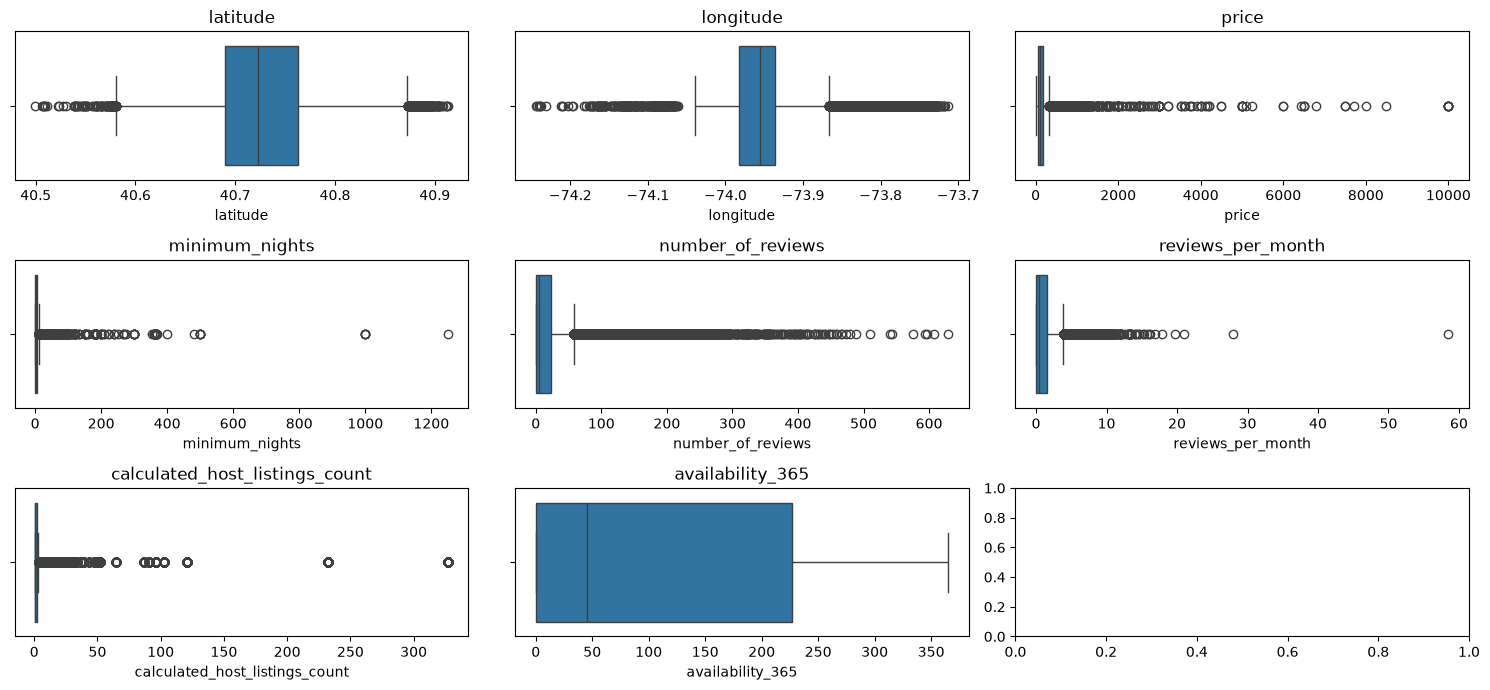

In [25]:

fig, axes = plt.subplots(3, 3, figsize=(15, 7))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

## Feature Distribution

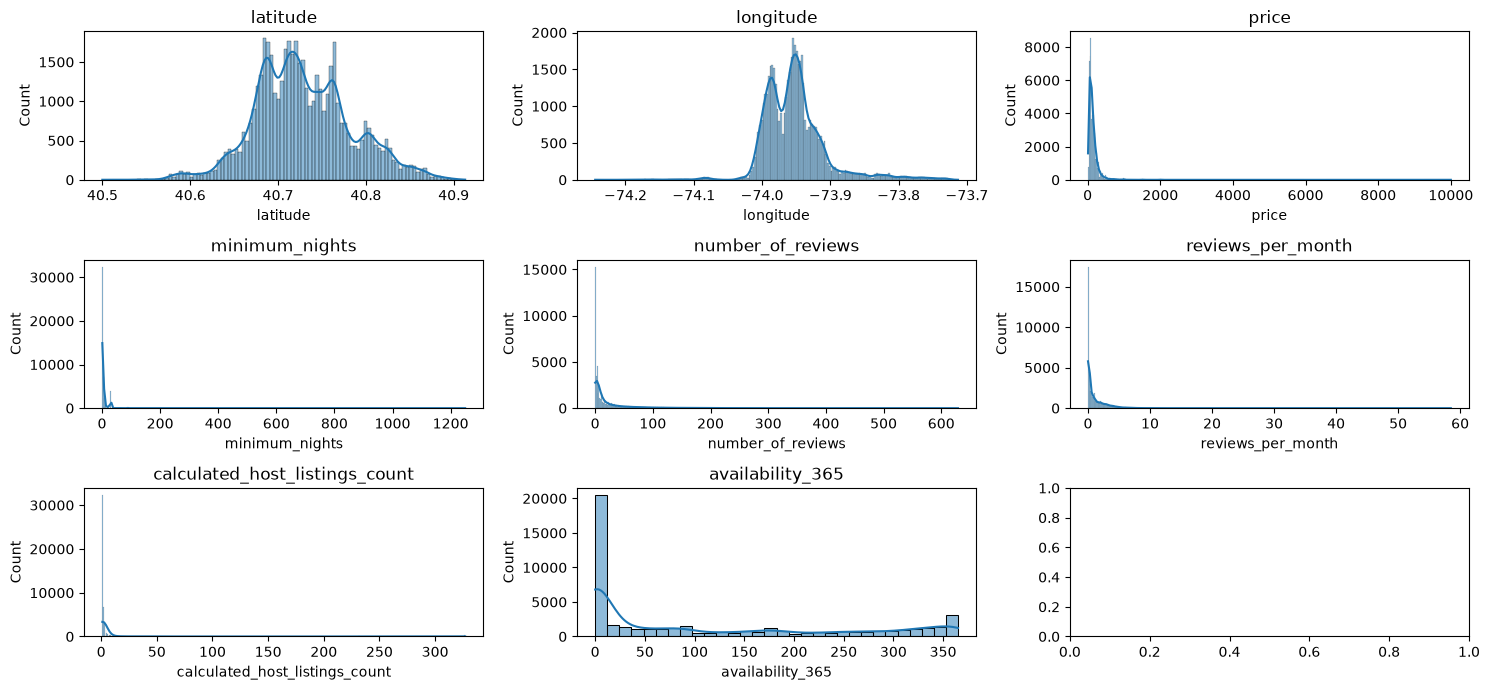

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(15, 7))

for ax, col in zip(axes.flatten(),num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [27]:
cat_cols = df.select_dtypes(include=['object','string']).columns
cat_cols

Index(['neighbourhood_group', 'neighbourhood', 'room_type'], dtype='str')

In [28]:
df[cat_cols].nunique()

neighbourhood_group      5
neighbourhood          221
room_type                3
dtype: int64

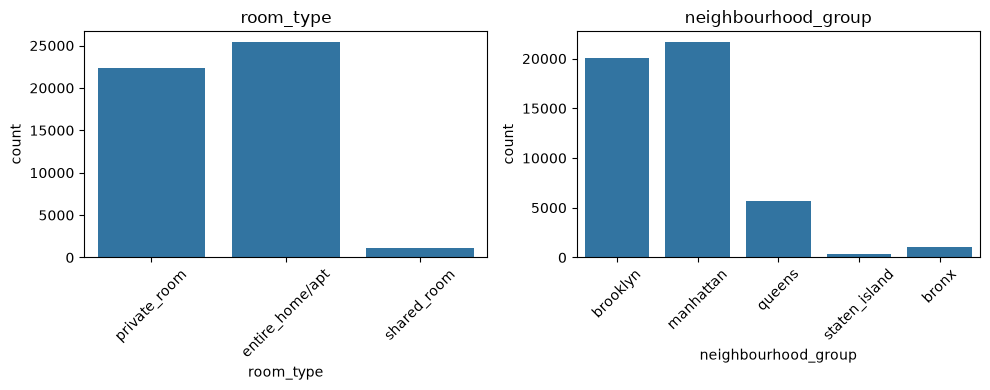

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ['room_type', 'neighbourhood_group']):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Outlier Analysis

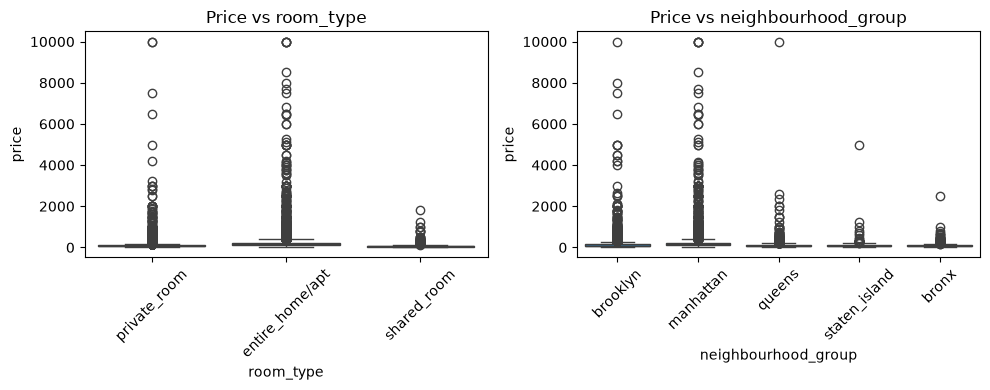

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


for ax, col in zip(axes, ['room_type', 'neighbourhood_group']):
    sns.boxplot(data=df, x=col, y='price', ax=ax)
    ax.set_title(f'Price vs {col}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [31]:
corr = df[list(num_cols)].corr()
corr

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
latitude,1.000000,0.084830,0.033899,0.024893,-0.015357,-0.018719,0.019518,-0.010942
longitude,0.084830,1.000000,-0.149954,-0.062772,0.059015,0.138435,-0.114715,0.082669
price,0.033899,-0.149954,1.000000,0.042805,-0.047926,-0.050531,0.057462,0.081847
minimum_nights,0.024893,-0.062772,0.042805,1.000000,-0.080080,-0.124870,0.127962,0.144275
number_of_reviews,-0.015357,0.059015,-0.047926,-0.080080,1.000000,0.589311,-0.072385,0.171975
reviews_per_month,-0.018719,0.138435,-0.050531,-0.124870,0.589311,1.000000,-0.047322,0.163664
calculated_host_listings_count,0.019518,-0.114715,0.057462,0.127962,-0.072385,-0.047322,1.000000,0.225712
availability_365,-0.010942,0.082669,0.081847,0.144275,0.171975,0.163664,0.225712,1.000000


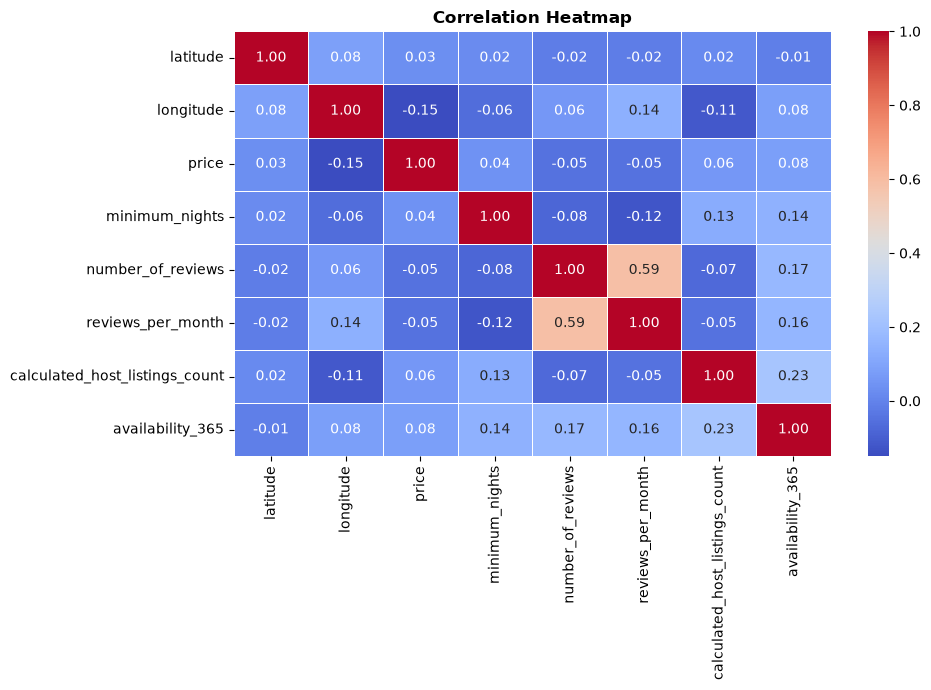

In [32]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

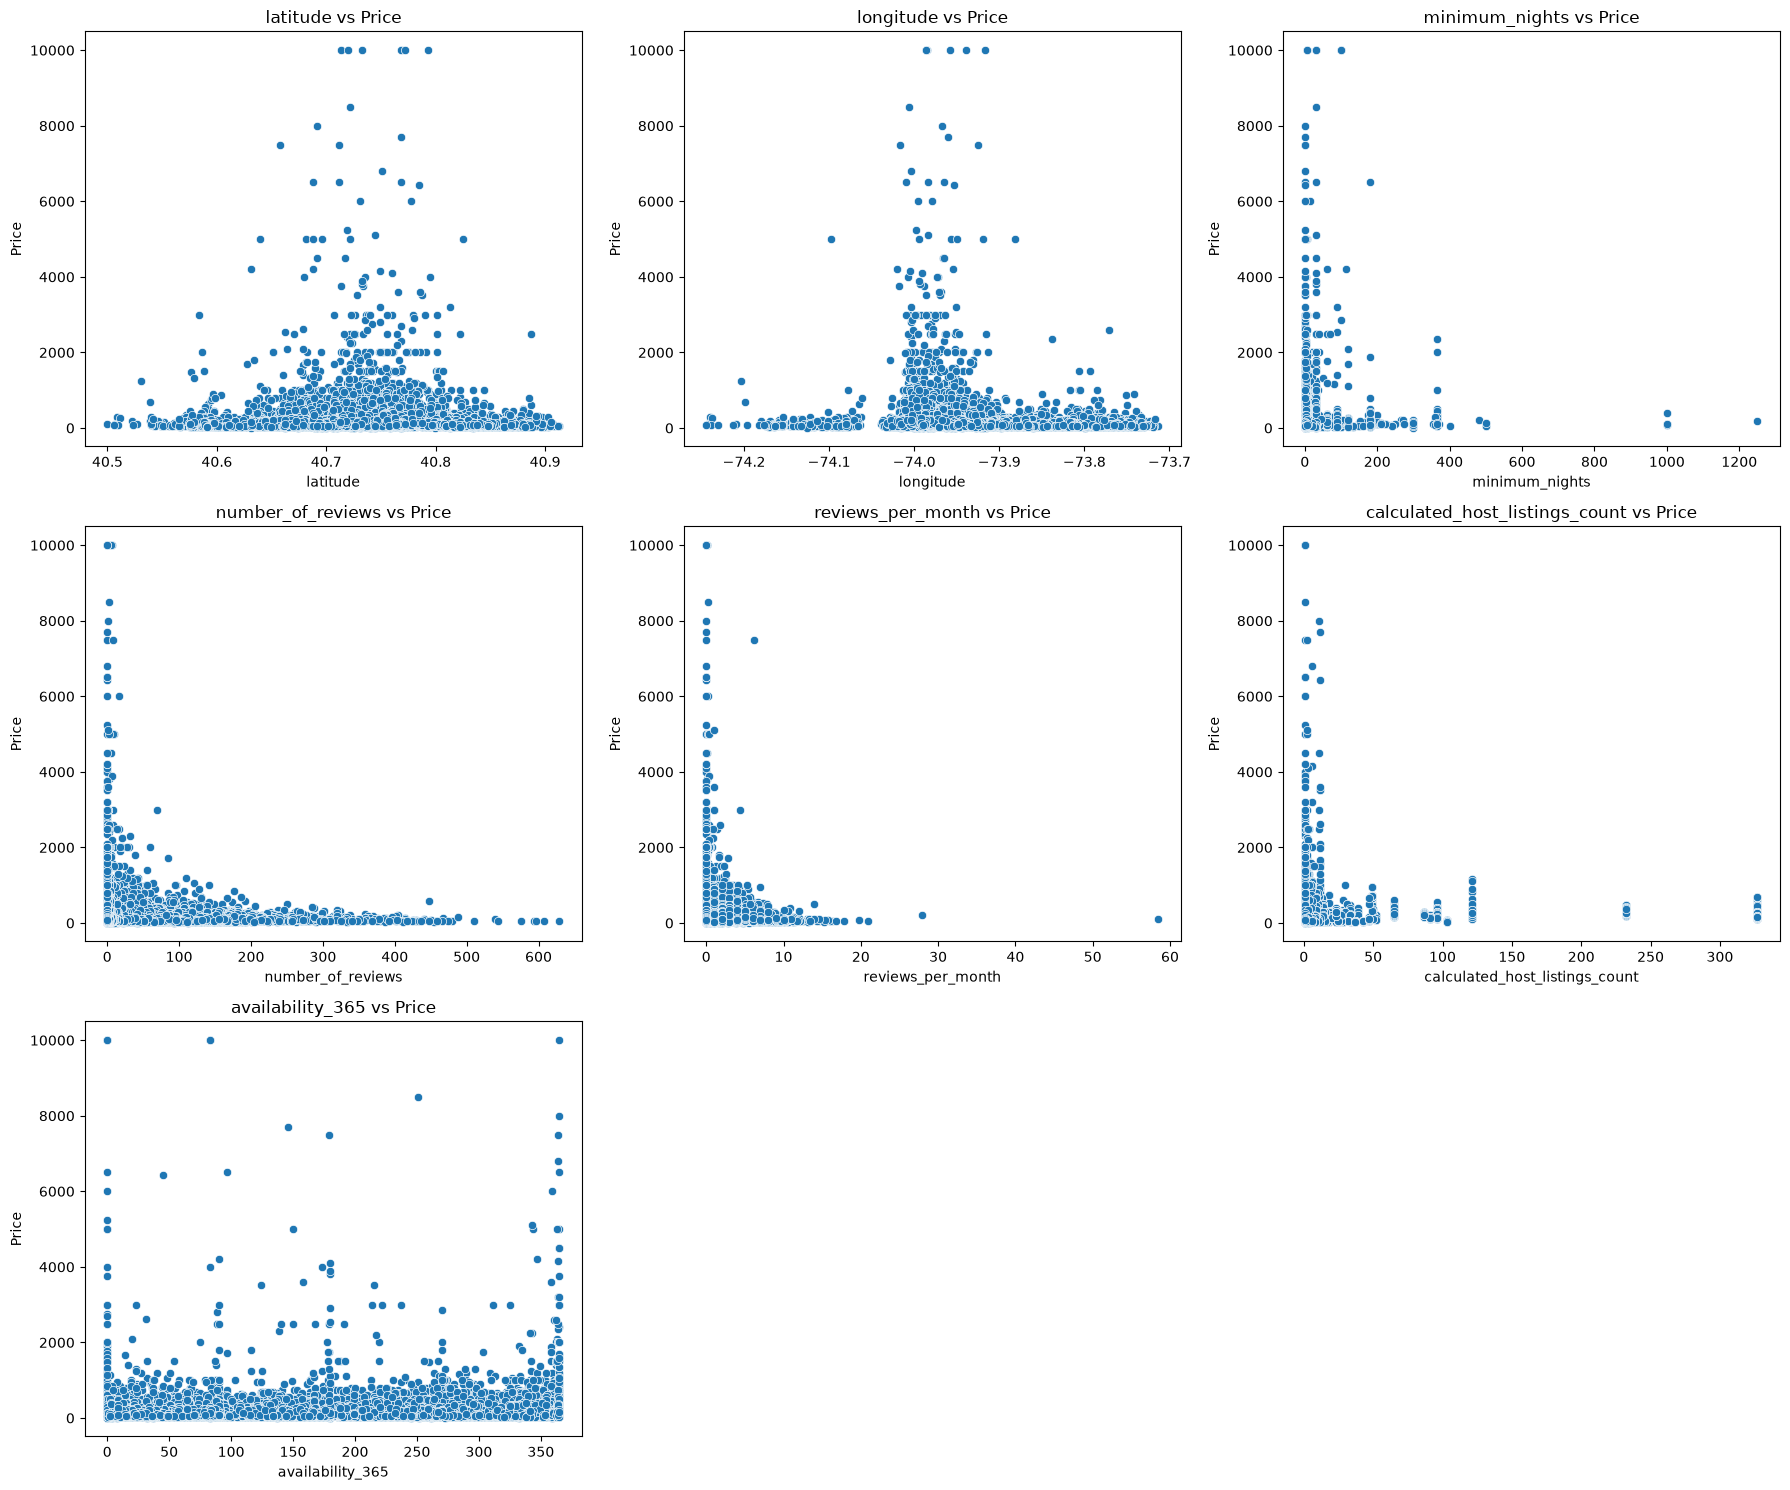

In [33]:
# Numerical features
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove target from feature list
num_cols.remove('price')

fig, axes = plt.subplots(
    nrows=(len(num_cols) + 2) // 3,
    ncols=3,
    figsize=(18, 5 * ((len(num_cols) + 2) // 3))
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(data=df, x=col, y='price', ax=axes[i])
    axes[i].set_title(f'{col} vs Price')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')

# Remove unused plots
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Train Test Split

In [34]:
# Features
X = df.drop('price', axis=1)

# Target
y = df['price']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (48884, 10)
y shape: (48884,)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [36]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (39107, 10)
X_test : (9777, 10)
y_train: (39107,)
y_test : (9777,)


# Feature Selection-Mutual Information

In [37]:
cat_cols = cat_cols.tolist()

In [38]:
from sklearn.feature_selection import mutual_info_regression

mi_X = X_train[cat_cols + num_cols].copy()

for col in cat_cols:
    mi_X[col] = mi_X[col].astype('category').cat.codes

mi_X.head(3)

,neighbourhood_group,neighbourhood,room_type,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,3,104,0,40.70840,-73.78882,3,6,3.05,1,37
1,1,212,1,40.70343,-73.93412,5,5,0.35,1,0
2,0,216,1,40.89981,-73.86684,2,7,1.84,1,70


In [39]:
discrete = [col in cat_cols for col in mi_X.columns]

mi_scores = mutual_info_regression(
    mi_X,
    y_train,
    discrete_features=discrete,
    random_state=1
)

mi = pd.DataFrame({
    'feature': mi_X.columns,
    'mutual_info': mi_scores,
    'kind': ['categorical' if d else 'numeric' for d in discrete]
})

mi = mi.sort_values(
    'mutual_info',
    ascending=False
).reset_index(drop=True)

mi.round(4)

,feature,mutual_info,kind
0,room_type,0.3022,categorical
1,neighbourhood,0.2300,categorical
2,longitude,0.1627,numeric
3,calculated_host_listings_count,0.1610,numeric
4,latitude,0.1287,numeric
5,neighbourhood_group,0.0900,categorical
6,minimum_nights,0.0503,numeric
7,availability_365,0.0371,numeric
8,number_of_reviews,0.0217,numeric
9,reviews_per_month,0.0123,numeric


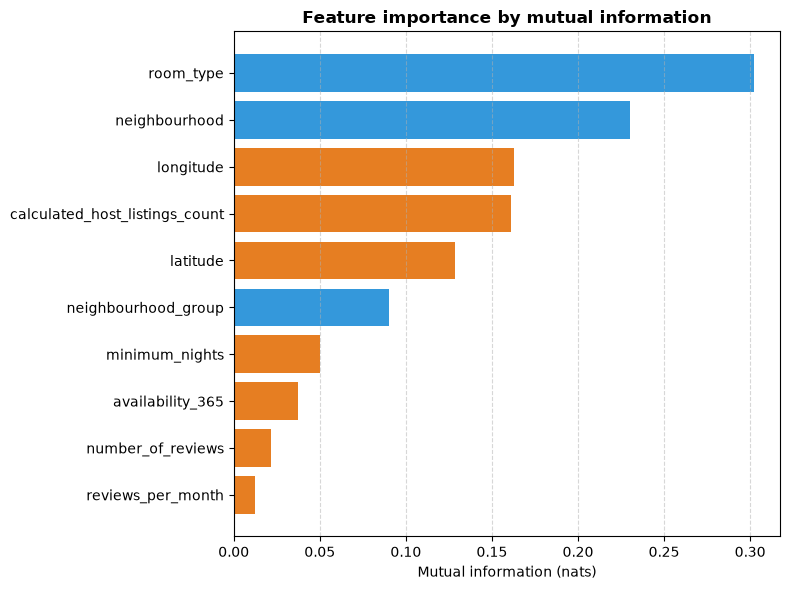

In [40]:
plt.figure(figsize=(8, 6))
colors = ['#3498db' if k == 'categorical' else '#e67e22' for k in mi.kind]
plt.barh(mi.feature[::-1], mi.mutual_info[::-1], color=colors[::-1])
plt.xlabel('Mutual information (nats)')
plt.title('Feature importance by mutual information', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [41]:
remove_cols = ['reviews_per_month', 'number_of_reviews']
X_train = X_train.drop(columns=remove_cols)
X_test = X_test.drop(columns=remove_cols)

# Handling outliers


In [42]:
percentiles = [0.90, 0.95, 0.98, 0.99, 0.995, 1.00]

for p in percentiles:
    print(f"{p*100:.1f}% of data is at or below {df['minimum_nights'].quantile(p)}")

90.0% of data is at or below 28.0
95.0% of data is at or below 30.0
98.0% of data is at or below 30.0
99.0% of data is at or below 45.0
99.5% of data is at or below 90.0
100.0% of data is at or below 1250.0


In [44]:
# Outlier treatment using IQR
# Calculate bounds only from X_train

outlier_cols = [
    'minimum_nights',
    'calculated_host_listings_count'
]

for column in outlier_cols:
    
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap outliers in training data
    X_train[column] = X_train[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )
    
    # Cap outliers in test data using the SAME bounds
    X_test[column] = X_test[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )
    
    print(f"{column}:")
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print()

minimum_nights:
Lower bound: -5.0
Upper bound: 11.0

calculated_host_listings_count:
Lower bound: -0.5
Upper bound: 3.5



# Data Preprocessing

In [98]:
# Apply a log transformation to reduce the effect of highly skewed prices
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [99]:
# One-hot encode categorical variables
# Align train and test columns so both datasets have the same features
X_train = pd.get_dummies(X_train, drop_first=True).astype(float)
X_test = pd.get_dummies(X_test, drop_first=True).astype(float)

# Make train and test have the same columns
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

ValueError: Data must be 1-dimensional, got ndarray of shape (39107, 228) instead

In [ ]:
# Standardize features before training the models

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training and Evaluation

## Linear regression

In [50]:
from sklearn.linear_model import LinearRegression


# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](228,)","[-0.02,-0.22,-0.09,...,-0.01,-0.35,-0.17]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.739
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,228
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(224)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](228,)","[367.92,337.64,288.12,..., 0. , 0. , 0. ]"


In [51]:
y_pred_log = model.predict(X_test)

In [52]:
y_pred = np.expm1(y_pred_log)

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_mae = mean_absolute_error(y_test_log, y_pred_log)
linear_r2 = r2_score(y_test_log, y_pred_log)
linear_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
    
print("MAE :", linear_mae)
print("R²  :", linear_r2)

MAE : 0.33809793533903537
R²  : 0.5326877324724304


In [54]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("R²  :", r2)

MAE : 59.63141274752516
R²  : 0.12697959757501642


## Decision Tree

In [55]:
from sklearn.tree import DecisionTreeRegressor
dtree_model = DecisionTreeRegressor(random_state=42)
dtree_model.fit(X_train, y_train_log)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [56]:
y_pred_log_dtree = dtree_model.predict(X_test)
y_pred_dtree = np.exp(y_pred_log_dtree)

In [57]:
mae_dtree = mean_absolute_error(y_test_log, y_pred_log_dtree)
r2_dtree = r2_score(y_test_log, y_pred_log_dtree)

print("mae_dtree :", mae_dtree)
print("r2_dtree :", r2_dtree)

mae_dtree : 0.4417088345790292
r2_dtree : 0.1891621006589228


In [58]:
# rows = []
# for depth in [5,8, 10, 15,20, None]:
#     for leaf in [1, 5, 10, 25, 27, 28, 30,32,34,35,40]:
#         dt_cv = DecisionTreeRegressor(max_depth=depth,
#                                        min_samples_leaf=leaf, random_state=42)
#         scores = cross_val_score(dt_cv, X_train, y_train_log, cv=5, scoring='r2')
#         rows.append({'max_depth': str(depth), 'min_samples_leaf': leaf, 'cv_r2': scores.mean()})

# dt_scores = pd.DataFrame(rows).sort_values('cv_r2', ascending=False).reset_index(drop=True)
# dt_scores.head(8).round(4)

In [59]:
dtree_model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=32, random_state=42)
dtree_model.fit(X_train, y_train_log)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",32
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

In [60]:
y_pred_log_tuned = dtree_model.predict(X_test)
y_pred_tuned = np.expm1(y_pred_log_tuned)

In [83]:
mae_tuned_log_dt = mean_absolute_error(y_test_log, y_pred_log_tuned)
r2_tuned_log_dt = r2_score(y_test_log, y_pred_log_tuned)
rmse_tuned_log_dt = np.sqrt(mean_squared_error(y_test_log, y_pred_log_tuned))

print("Tuned MAE (log):", mae_tuned_log_dt)
print("Tuned R² (log):", r2_tuned_log_dt)
print("Tuned RMSE (log):", rmse_tuned_log_dt)

Tuned MAE (log): 0.33465025794419007
Tuned R² (log): 0.5448191209953519
Tuned RMSE (log): 0.4675396024520848


## random forest

In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train_log)

y_pred_log_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test_log, y_pred_log_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_log, y_pred_log_rf))
r2_rf = r2_score(y_test_log, y_pred_log_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest
MAE: 0.3210037725408776
RMSE: 0.45490753972770803
R2: 0.5690831528196345


In [63]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

for n in [10, 25, 50, 100, 200, 300]:

    rf_cv = RandomForestRegressor(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        rf_cv,
        X_train,
        y_train_log,
        cv=5,
        scoring='r2'
    )

    print(
        f'n_estimators={n:3d}: '
        f'cv R2 {scores.mean():.3f} (+/- {scores.std():.3f})'
    )

n_estimators= 10: cv R2 0.540 (+/- 0.010)
n_estimators= 25: cv R2 0.563 (+/- 0.010)
n_estimators= 50: cv R2 0.571 (+/- 0.010)
n_estimators=100: cv R2 0.576 (+/- 0.010)
n_estimators=200: cv R2 0.577 (+/- 0.010)
n_estimators=300: cv R2 0.578 (+/- 0.010)


In [64]:
rows = []

for depth in [5, 8, 10, 15, 20, None]:

    for leaf in [1, 2, 5, 10, 25]:

        rf_cv = RandomForestRegressor(
            n_estimators=200,
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=42,
            n_jobs=-1
        )

        scores = cross_val_score(
            rf_cv,
            X_train,
            y_train_log,
            cv=5,
            scoring='r2'
        )

        rows.append({
            'max_depth': str(depth),
            'min_samples_leaf': leaf,
            'cv_r2': scores.mean()
        })

rf_scores = (
    pd.DataFrame(rows)
    .sort_values('cv_r2', ascending=False)
    .reset_index(drop=True)
)

rf_scores.head(10).round(4)

,max_depth,min_samples_leaf,cv_r2
0,15,5,0.5926
1,15,2,0.5916
2,20,5,0.5915
3,15,10,0.5908
4,20,10,0.5906
5,None,10,0.5904
6,None,5,0.5903
7,15,1,0.5893
8,20,2,0.5884
9,20,1,0.5846


In [ ]:
best = rf_scores.iloc[0]

best_depth = None if best['max_depth'] == 'None' else int(best['max_depth'])
best_leaf = int(best['min_samples_leaf'])

# best_depth, best_leaf = 15,5

print("Best parameters:")
print("max_depth:", best_depth)
print("min_samples_leaf:", best_leaf)

Best parameters:
max_depth: 15
min_samples_leaf: 5


In [66]:
rf_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train_log)

y_pred_log_rf = rf_final.predict(X_test)

In [67]:
mae_rf = mean_absolute_error(y_test_log, y_pred_log_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test_log, y_pred_log_rf)
)

r2_rf = r2_score(
    y_test_log,
    y_pred_log_rf
)

print("Tuned Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Tuned Random Forest
MAE: 0.3169189820261921
RMSE: 0.448751596670047
R2: 0.5806668298838671


# XGboost

In [75]:
import sys
print(sys.executable)

/home/rashna/Desktop/ApartmentPrice/.venv/bin/python


In [76]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

xgb.fit(X_train, y_train_log)

y_pred_log_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test_log, y_pred_log_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_log, y_pred_log_xgb))
r2_xgb = r2_score(y_test_log, y_pred_log_xgb)

print("XGBoost")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost
MAE: 0.32059541973939887
RMSE: 0.4508222306162497
R2: 0.5767881195731881


In [77]:
from sklearn.model_selection import cross_val_score

for n in [50, 100, 200, 300, 500]:

    xgb_cv = XGBRegressor(
        n_estimators=n,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    )

    scores = cross_val_score(
        xgb_cv,
        X_train,
        y_train_log,
        cv=5,
        scoring='r2'
    )

    print(
        f'n_estimators={n:3d}: '
        f'cv R2 {scores.mean():.3f} (+/- {scores.std():.3f})'
    )

n_estimators= 50: cv R2 0.569 (+/- 0.008)
n_estimators=100: cv R2 0.584 (+/- 0.009)
n_estimators=200: cv R2 0.588 (+/- 0.009)
n_estimators=300: cv R2 0.589 (+/- 0.009)
n_estimators=500: cv R2 0.589 (+/- 0.009)


In [78]:
rows = []

for depth in [3, 4, 5, 6, 8, 10]:

    for lr in [0.01, 0.03, 0.05, 0.1]:

        xgb_cv = XGBRegressor(
            n_estimators=200,
            max_depth=depth,
            learning_rate=lr,
            random_state=42,
            objective='reg:squarederror',
            n_jobs=-1
        )

        scores = cross_val_score(
            xgb_cv,
            X_train,
            y_train_log,
            cv=5,
            scoring='r2'
        )

        rows.append({
            'max_depth': depth,
            'learning_rate': lr,
            'cv_r2': scores.mean()
        })

xgb_scores = (
    pd.DataFrame(rows)
    .sort_values('cv_r2', ascending=False)
    .reset_index(drop=True)
)

xgb_scores.head(10).round(4)

,max_depth,learning_rate,cv_r2
0,8,0.03,0.5897
1,8,0.10,0.5897
2,8,0.05,0.5893
3,6,0.10,0.5889
4,6,0.05,0.5877
5,10,0.03,0.5871
6,10,0.05,0.5869
7,5,0.10,0.5865
8,6,0.03,0.5856
9,5,0.05,0.5839


In [79]:
xgb_final = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.03,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

xgb_final.fit(X_train, y_train_log)

y_pred_log_xgb = xgb_final.predict(X_test)

mae_xgb = mean_absolute_error(y_test_log, y_pred_log_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_log, y_pred_log_xgb))
r2_xgb = r2_score(y_test_log, y_pred_log_xgb)

print("XGBoost Final")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost Final
MAE: 0.3183630257834556
RMSE: 0.4479809144480334
R2: 0.5821059116152056


# Model Comparison

In [86]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        linear_mae,
        mae_tuned_log_dt,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        linear_rmse,
        rmse_tuned_log_dt,
        rmse_rf,
        rmse_xgb
    ],
    "R2": [
        linear_r2,
        r2_tuned_log_dt,
        r2_rf,
        r2_xgb
    ]
})

comparison
comparison.round(4)
comparison.sort_values("R2", ascending=False).round(4)

,Model,MAE,RMSE,R2
3,XGBoost,0.3184,0.4480,0.5821
2,Random Forest,0.3169,0.4488,0.5807
1,Decision Tree,0.3347,0.4675,0.5448
0,Linear Regression,0.3381,0.4737,0.5327


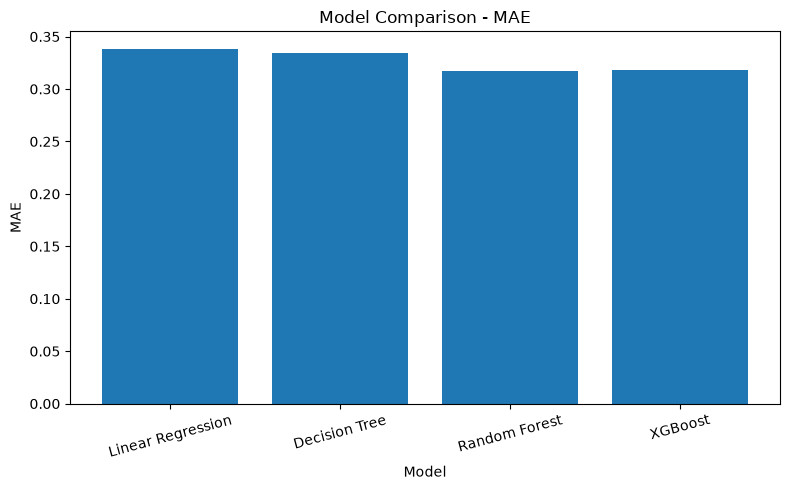

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(comparison["Model"], comparison["MAE"])

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

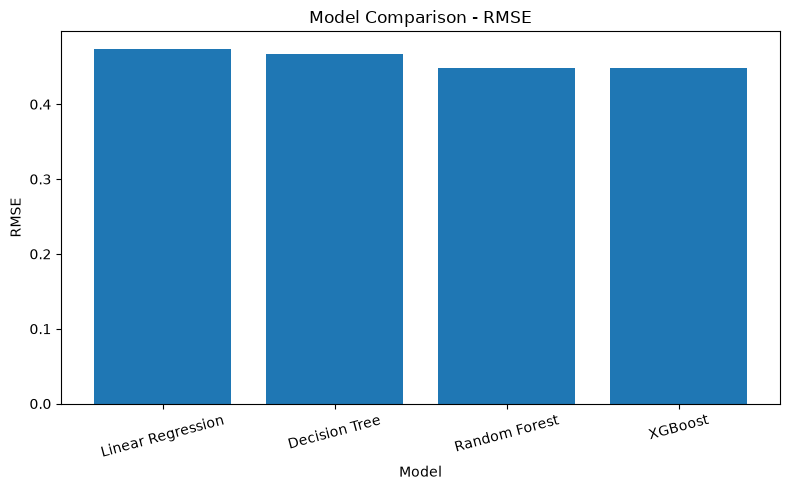

In [88]:
plt.figure(figsize=(8, 5))

plt.bar(comparison["Model"], comparison["RMSE"])

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

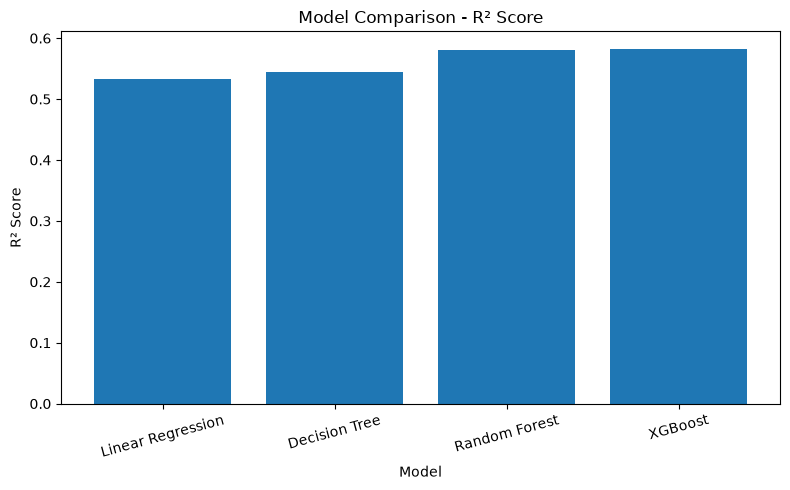

In [89]:
plt.figure(figsize=(8, 5))

plt.bar(comparison["Model"], comparison["R2"])

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Conclusion

Four regression models were evaluated for Airbnb price prediction: Linear Regression, Decision Tree, Random Forest, and XGBoost.

The ensemble models performed better than the individual regression models. XGBoost achieved the highest R² score (0.5821) and the lowest RMSE (0.4480), while Random Forest achieved the lowest MAE (0.3169).

Based on the highest R² score and lowest RMSE, XGBoost was selected as the final model. These results suggest that ensemble tree-based models are better able to capture the complex relationships in the Airbnb pricing data.

The evaluation metrics were calculated using the log-transformed target variable.
